# 02 — Centrality

**Centrality** asks a deceptively simple question: which nodes are the *important* ones? There's no single answer, because "important" can mean several different things, and each has its own definition. For Lightning, importance mostly means **routing relevance** — which nodes actually carry payments, earn forwarding fees, and would do the most damage if they went offline.

This notebook computes five centrality measures on the channel graph and compares them. They often disagree, and the disagreements are the interesting part: a node can be a giant by one measure and ordinary by another.

1. **Degree** — how many channels (and how much capacity) a node has.
2. **Closeness** — how few hops it takes to reach everyone else.
3. **Eigenvector** — whether a node is connected to *other* important nodes.
4. **Betweenness** — how many payment paths pass through the node.
5. A k-sampling convergence check and an igraph-vs-NetworkX cross-validation.

In [1]:
%matplotlib inline
import os
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from scipy.stats import spearmanr

from lngraph.ingest import ingest
from lngraph.graph import simplify, largest_connected_component
import lngraph.centrality as cent

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})

_here = Path().resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / "lngraph").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

_override = os.environ.get("LNGRAPH_SNAPSHOT_DIR")
SNAPSHOT_DIR = Path(_override) if _override else PROJECT_ROOT / "data" / "snapshots"
SNAPSHOT_PATH = SNAPSHOT_DIR / "describegraph.json"

try:
    _disp = SNAPSHOT_PATH.relative_to(PROJECT_ROOT)
except ValueError:
    _disp = SNAPSHOT_PATH
print(f"Snapshot path : {_disp}")

Snapshot path : data/snapshots/describegraph.json


In [2]:
if not SNAPSHOT_PATH.exists():
    raise FileNotFoundError(
        f"No snapshot at {SNAPSHOT_PATH} — run `make crawl` to build one.\n"
        "This notebook requires real Lightning Network data and has no synthetic fallback."
    )

dg = json.loads(SNAPSHOT_PATH.read_text())
print(f"Loaded snapshot: {len(dg['nodes'])} nodes, {len(dg['edges'])} channels")

G = ingest(dg)
G_simple = simplify(G)
n_nodes = G.number_of_nodes()
n_channels = len({d.get('channel_id') for _, _, d in G.edges(data=True)})
alias_map = {n: G.nodes[n].get('alias', n[:8]) for n in G.nodes()}

print(f"\nGraph: {n_nodes:,} nodes, {n_channels:,} channels")

Loaded snapshot: 9990 nodes, 44501 channels



Graph: 9,990 nodes, 44,501 channels


## 1 · Degree centrality

The simplest measure: count a node's channels, normalised by the most it could have (n−1). **Capacity-weighted degree** instead sums the sizes of its channels, so a node with a few huge channels can outweigh one with many tiny ones.

The two rankings tell different stories. **ACINQ leads on raw degree (0.130)** — it has the most channels. But on capacity-weighted degree the leader is **bfx-lnd0 (1.00, the reference maximum)**, with ACINQ at 0.66 and Kraken at 0.51. That split reflects two real strategies: open *many* modest channels to maximise reach (ACINQ, WalletOfSatoshi), or open *few, very large* channels to move size (the exchange nodes). Both are forms of importance; degree alone hides the difference.

In [3]:
deg_result = cent.degree_centrality(G)

df_deg = pd.DataFrame({
    "alias":            [alias_map.get(n, n[:8]) for n in G.nodes()],
    "in_degree":        [deg_result["in_degree"][n]       for n in G.nodes()],
    "out_degree":       [deg_result["out_degree"][n]      for n in G.nodes()],
    "total_degree":     [deg_result["total_degree"][n]    for n in G.nodes()],
    "cap_weighted":     [deg_result["capacity_weighted"][n] for n in G.nodes()],
}, index=list(G.nodes()))

TOP = min(10, n_nodes)
print(f"Top-{TOP} by total degree centrality:")
print(df_deg.sort_values("total_degree", ascending=False).head(TOP)[
    ["alias", "in_degree", "out_degree", "total_degree", "cap_weighted"]
].to_string())

Top-10 by total degree centrality:
                                                                                  alias  in_degree  out_degree  total_degree  cap_weighted
03864ef025fde8fb587d989186ce6a4a186895ee44a926bfc370e2c366597a3f8f                ACINQ   0.129643    0.129643      0.129643      0.655780
035e4ff418fc8b5554c5d9eea66396c227bd429a3251c8cbc711002ba215bfc226  WalletOfSatoshi.com   0.089799    0.089799      0.089799      0.254220
0217890e3aad8d35bc054f43acc00084b25229ecff0ab68debd82883ad65ee8266   1ML.com node ALPHA   0.084993    0.084993      0.084993      0.011432
02f1a8c87607f415c8f22c00593002775941dea48869ce23096af27b0cfdcc0b69            Kraken 🐙⚡   0.080889    0.080889      0.080889      0.511810
0242a4ae0c5bef18048fbecf995094b74bfb0f7391418d71ed394784373f41e4f3             CoinGate   0.069076    0.069076      0.069076      0.026740
0324ba2392e25bff76abd0b1f7e4b53b5f82aa53fddc3419b051b6c801db9e2247                kappa   0.051356    0.051356      0.051356      0

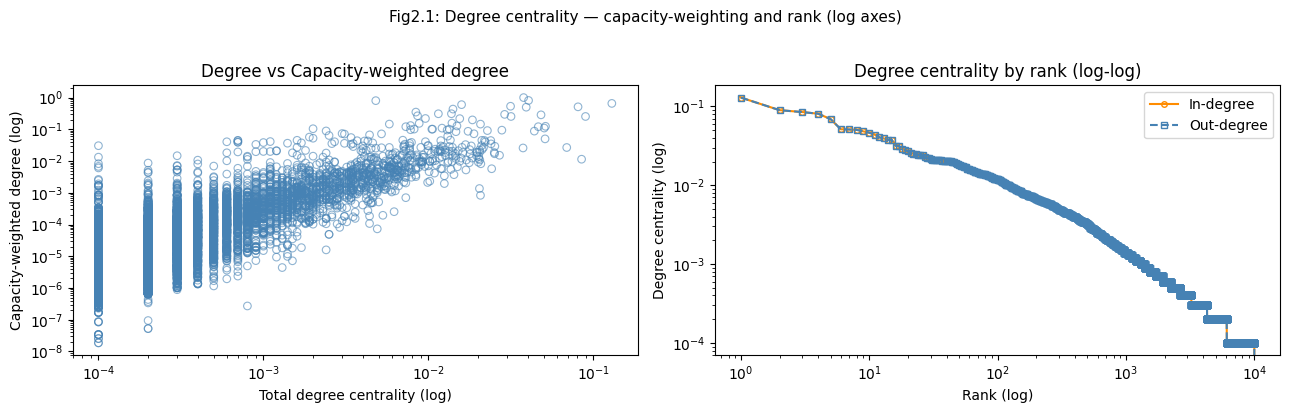

In [4]:
if n_nodes >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    td = df_deg["total_degree"]
    cw = df_deg["cap_weighted"]
    axes[0].scatter(td, cw, facecolors="none", edgecolors="steelblue", alpha=0.6, s=30, linewidths=0.8, zorder=3)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Total degree centrality (log)")
    axes[0].set_ylabel("Capacity-weighted degree (log)")
    axes[0].set_title("Degree vs Capacity-weighted degree")

    in_d = sorted(deg_result["in_degree"].values(), reverse=True)
    axes[1].plot(range(1, len(in_d) + 1), in_d, "o-", markersize=4, markerfacecolor="none",
                 color="darkorange", label="In-degree")
    out_d = sorted(deg_result["out_degree"].values(), reverse=True)
    axes[1].plot(range(1, len(out_d) + 1), out_d, "s--", markersize=4, markerfacecolor="none",
                 color="steelblue", label="Out-degree")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Rank (log)")
    axes[1].set_ylabel("Degree centrality (log)")
    axes[1].set_title("Degree centrality by rank (log-log)")
    axes[1].legend()

    plt.suptitle("Fig2.1: Degree centrality — capacity-weighting and rank (log axes)", y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Graph too small for plot.")

## 2 · Closeness centrality

Closeness measures how near a node is to *everyone else*, in hops. Formally it's the inverse of the average shortest-path distance to all reachable nodes (Wasserman–Faust normalisation for directed graphs). A high score means the node sits in the middle of things and can reach the whole network in few steps — an efficient place to originate or forward payments from.

The top scores cluster tightly: **ACINQ leads at 0.391**, with cyberdyne.sh, Sunny Sarah, Vix18 and LQwD-Canada all within a whisker (~0.37–0.39), against a network **mean of 0.25**. The flatness at the top is itself a finding — the well-connected core is a *plateau* of near-equally-central hubs, not a single dominant node. Any of them is roughly 2–3 hops from most of the network.

In [5]:
close_result = cent.closeness_centrality(G)

df_close = pd.DataFrame({
    "alias":     [alias_map.get(n, n[:8]) for n in close_result],
    "closeness": list(close_result.values()),
}, index=list(close_result.keys()))

print(f"Top-{TOP} by closeness centrality:")
print(df_close.sort_values("closeness", ascending=False).head(TOP).to_string())
print(f"\nMean: {np.mean(list(close_result.values())):.4f}   "
      f"Max: {max(close_result.values()):.4f}   "
      f"Min: {min(close_result.values()):.4f}")

Top-10 by closeness centrality:
                                                                                        alias  closeness
03864ef025fde8fb587d989186ce6a4a186895ee44a926bfc370e2c366597a3f8f                      ACINQ   0.390971
03a93b87bf9f052b8e862d51ebbac4ce5e97b5f4137563cd5128548d7f5978dda9               cyberdyne.sh   0.388129
03423790614f023e3c0cdaa654a3578e919947e4c3a14bf5044e7c787ebd11af1a             Sunny Sarah ☀️   0.382391
03d32e5618df518e911e2c0bf4686e9d236ae9ab0afd442f0a5de28b74d64338b3                    🇨🇭Vix18   0.381267
0364913d18a19c671bb36dd04d6ad5be0fe8f2894314c36a9db3f03c2d414907e1                LQwD-Canada   0.376140
03cde60a6323f7122d5178255766e38114b4722ede08f7c9e0c5df9b912cc201d6                   bfx-lnd1   0.374742
035e4ff418fc8b5554c5d9eea66396c227bd429a3251c8cbc711002ba215bfc226        WalletOfSatoshi.com   0.374391
02ad6fb8d693dc1e4569bcedefadf5f72a931ae027dc0f0c544b34c1c6f3b9a02b  rompert.hashposition.com🔵   0.371715
0340cfadaa3324e0dd176a9

## 3 · Eigenvector centrality

Degree counts your neighbours; eigenvector centrality weighs *who* they are. A node connected to other highly-central nodes scores higher than one with the same number of channels to obscure peers. Mathematically the scores are the leading eigenvector of the adjacency matrix, found by repeatedly averaging each node's score over its neighbours until the values settle.

For Lightning, a high eigenvector score means a node is wired into the **well-connected core**, not just the periphery. **ACINQ (0.176), Sunny Sarah (0.163), WalletOfSatoshi (0.161) and Kraken (0.159)** lead — the inner circle that routes among itself. Compare this with betweenness below, which can crown a very different node.

In [6]:
eigen_result = cent.eigenvector_centrality(G)

df_eigen = pd.DataFrame({
    "alias":      [alias_map.get(n, n[:8]) for n in eigen_result],
    "eigenvector": list(eigen_result.values()),
}, index=list(eigen_result.keys()))

print(f"Top-{TOP} by eigenvector centrality:")
print(df_eigen.sort_values("eigenvector", ascending=False).head(TOP).to_string())

Top-10 by eigenvector centrality:
                                                                                  alias  eigenvector
03864ef025fde8fb587d989186ce6a4a186895ee44a926bfc370e2c366597a3f8f                ACINQ     0.176366
03423790614f023e3c0cdaa654a3578e919947e4c3a14bf5044e7c787ebd11af1a       Sunny Sarah ☀️     0.162509
035e4ff418fc8b5554c5d9eea66396c227bd429a3251c8cbc711002ba215bfc226  WalletOfSatoshi.com     0.161314
02f1a8c87607f415c8f22c00593002775941dea48869ce23096af27b0cfdcc0b69            Kraken 🐙⚡     0.159270
03a93b87bf9f052b8e862d51ebbac4ce5e97b5f4137563cd5128548d7f5978dda9         cyberdyne.sh     0.129216
0298f6074a454a1f5345cb2a7c6f9fce206cd0bf675d177cdbf0ca7508dd28852f       BCash_Is_Trash     0.128836
03d32e5618df518e911e2c0bf4686e9d236ae9ab0afd442f0a5de28b74d64338b3              🇨🇭Vix18     0.128771
0364913d18a19c671bb36dd04d6ad5be0fe8f2894314c36a9db3f03c2d414907e1          LQwD-Canada     0.128524
0324ba2392e25bff76abd0b1f7e4b53b5f82aa53fddc3419b051b6c80

## 4 · Betweenness centrality

Betweenness is the most routing-relevant measure: the fraction of all shortest paths that pass **through** a node. A high-betweenness node is a toll booth — most traffic crosses it, so it captures the most forwarding fees, and its failure would reroute or break the most payments.

Note who tops it: **1ML.com node ALPHA (0.18)**, *above* ACINQ (0.13) — even though 1ML has fewer channels and far less capacity (capacity-weighted degree just 0.011). It ranks first because it **bridges** otherwise-distant parts of the graph; payments have to pass through it. Betweenness rewards position, not size.

Computing it exactly is O(V·E) — too slow at scale — so we use two routes and compare:
- **Sampled (NetworkX):** estimate from k random "pivot" nodes instead of all of them.
- **Exact (igraph):** the full Brandes algorithm in compiled C, fast enough at this graph size to give a ground truth.

The **fee-based** column re-weights paths by real routing cost (fees + time-lock) instead of hop count, which shifts the ranking — e.g. LQwD-Canada rises because it sits on many *cheap* paths.

In [7]:
btwn_sampled = cent.betweenness_sampled(G, k=min(500, n_nodes), seed=42)
btwn_exact   = cent.betweenness_exact(G)
btwn_fee     = cent.betweenness_fee(G, k=min(500, n_nodes), seed=42, amount_msat=100_000)

df_btwn = pd.DataFrame({
    "alias":       [alias_map.get(n, n[:8]) for n in btwn_sampled],
    "sampled_nx":  list(btwn_sampled.values()),
    "exact_igraph": [btwn_exact.get(n, 0.0) for n in btwn_sampled],
    "fee_based":   [btwn_fee.get(n, 0.0)  for n in btwn_sampled],
}, index=list(btwn_sampled.keys()))

print(f"Top-{TOP} by betweenness (sampled nx):")
print(df_btwn.sort_values("sampled_nx", ascending=False).head(TOP).to_string())

Top-10 by betweenness (sampled nx):
                                                                                  alias  sampled_nx  exact_igraph  fee_based
0217890e3aad8d35bc054f43acc00084b25229ecff0ab68debd82883ad65ee8266   1ML.com node ALPHA    0.175651      0.180455   0.077045
03864ef025fde8fb587d989186ce6a4a186895ee44a926bfc370e2c366597a3f8f                ACINQ    0.118635      0.134076   0.049563
0242a4ae0c5bef18048fbecf995094b74bfb0f7391418d71ed394784373f41e4f3             CoinGate    0.109426      0.120931   0.069243
035e4ff418fc8b5554c5d9eea66396c227bd429a3251c8cbc711002ba215bfc226  WalletOfSatoshi.com    0.065443      0.066524   0.030447
02f1a8c87607f415c8f22c00593002775941dea48869ce23096af27b0cfdcc0b69            Kraken 🐙⚡    0.051003      0.045319   0.023147
03c2abfa93eacec04721c019644584424aab2ba4dff3ac9bdab4e9c97007491dda            tippin.me    0.046209      0.042404   0.032038
033d8656219478701227199cbd6f670335c8d408a92ae88b962c49d4dc0e83e025             bfx-lnd0  

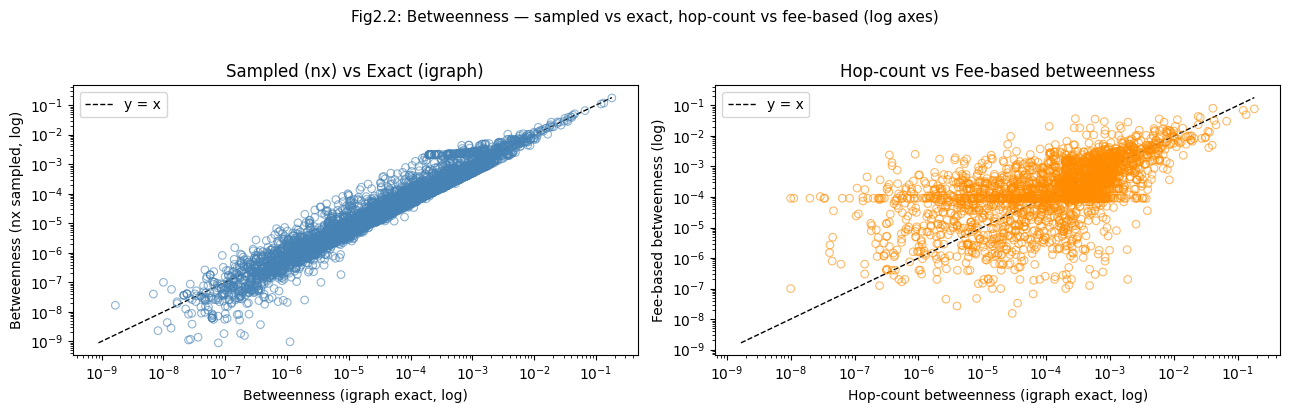

In [8]:
if n_nodes >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    s_vals = df_btwn["sampled_nx"].values
    e_vals = df_btwn["exact_igraph"].values
    f_vals = df_btwn["fee_based"].values

    # Betweenness has many exact-zero nodes (leaves never on a shortest path);
    # log axes drop those. The y=x validation is meaningful only on the nonzero
    # values, where log-log shows the agreement holds across orders of magnitude.
    axes[0].scatter(e_vals, s_vals, facecolors="none", edgecolors="steelblue", alpha=0.6, s=30, linewidths=0.8, zorder=3)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    _pos0 = np.concatenate([e_vals[e_vals > 0], s_vals[s_vals > 0]])
    _lo = _pos0.min()
    _hi = max(e_vals.max(), s_vals.max())
    axes[0].plot([_lo, _hi], [_lo, _hi], "k--", lw=1, label="y = x")
    axes[0].set_xlabel("Betweenness (igraph exact, log)")
    axes[0].set_ylabel("Betweenness (nx sampled, log)")
    axes[0].set_title("Sampled (nx) vs Exact (igraph)")
    axes[0].legend()

    axes[1].scatter(e_vals, f_vals, facecolors="none", edgecolors="darkorange", alpha=0.6, s=30, linewidths=0.8, zorder=3)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    _pos1 = np.concatenate([e_vals[e_vals > 0], f_vals[f_vals > 0]])
    _lo2 = _pos1.min()
    _hi2 = max(e_vals.max(), f_vals.max())
    axes[1].plot([_lo2, _hi2], [_lo2, _hi2], "k--", lw=1, label="y = x")
    axes[1].set_xlabel("Hop-count betweenness (igraph exact, log)")
    axes[1].set_ylabel("Fee-based betweenness (log)")
    axes[1].set_title("Hop-count vs Fee-based betweenness")
    axes[1].legend()

    plt.suptitle("Fig2.2: Betweenness — sampled vs exact, hop-count vs fee-based (log axes)", y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Graph too small for scatter plot.")

## 5 · How few samples does the approximation need?

Sampled betweenness is only useful if a small number of pivots reproduces the true ranking. We test this directly: for each k, compute the **Spearman rank correlation** between the k-sampled top-N ordering and the igraph-exact ordering. A correlation near 1.0 means the cheap estimate ranks the important nodes in the right order.

The result is striking: **k = 1 already clears 0.95.** A single pivot is enough to recover the top ranking — because the hub structure is so dominant that the same few nodes sit on nearly everyone's shortest paths no matter which pivot you sample from. In a flatter network you'd need far more. This is the practical payoff of the skew seen in notebook 01: expensive global metrics become cheap to approximate.

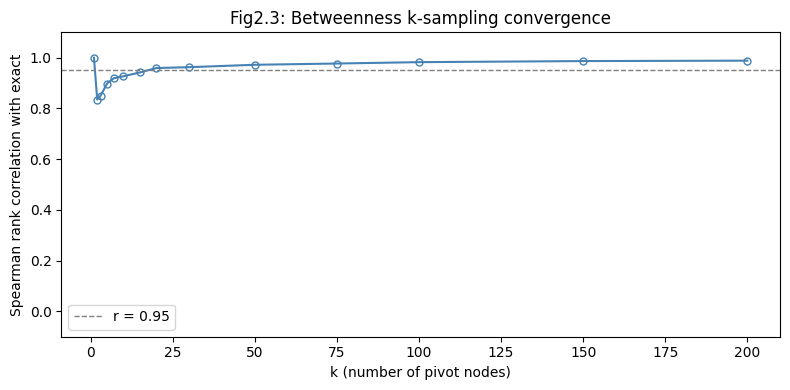

First k where Spearman ≥ 0.95: k = 1
Max k tested: 200   (n_nodes = 9990)


In [9]:
exact_nodes = list(btwn_exact.keys())
exact_vals  = np.array([btwn_exact[n] for n in exact_nodes])

max_k = min(n_nodes, 200)
k_values = sorted(set(
    [1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, max_k]
) & set(range(1, max_k + 1)))

if n_nodes < 4:
    print("Graph too small for meaningful k-sampling convergence analysis.")
else:
    corrs = []
    for k_val in k_values:
        sampled_k = cent.betweenness_sampled(G, k=k_val, seed=42)
        sampled_vals = np.array([sampled_k[n] for n in exact_nodes])
        if exact_vals.std() > 0 and sampled_vals.std() > 0:
            corr, _ = spearmanr(exact_vals, sampled_vals)
        else:
            corr = 1.0
        corrs.append(corr)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(k_values, corrs, "o-", color="steelblue", markersize=5, markerfacecolor="none")
    ax.axhline(0.95, color="gray", lw=1, linestyle="--", label="r = 0.95")
    ax.set_xlabel("k (number of pivot nodes)")
    ax.set_ylabel("Spearman rank correlation with exact")
    ax.set_title("Fig2.3: Betweenness k-sampling convergence")
    ax.set_ylim([-0.1, 1.1])
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Find k where correlation first exceeds 0.95
    first_good = next((k_values[i] for i, c in enumerate(corrs) if c >= 0.95), None)
    print(f"First k where Spearman ≥ 0.95: k = {first_good}")
    print(f"Max k tested: {max_k}   (n_nodes = {n_nodes})")

## 6 · Cross-validating the two implementations

NetworkX (pure Python) and igraph (compiled C) run the *same* Brandes algorithm; igraph is simply 10–100× faster on large graphs. Running both and plotting one against the other is a correctness check — the points should fall exactly on the y = x line. They do: the **maximum difference is 5.6 × 10⁻¹⁷**, i.e. floating-point noise. That agreement lets us trust the fast igraph path for the heavy computations and use NetworkX for everything else.

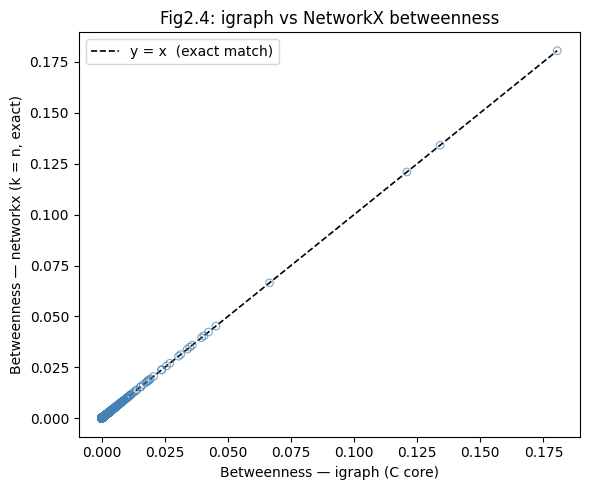

Max absolute difference (igraph vs nx): 5.55e-17
Results are numerically identical (diff < 1e-8).


In [10]:
# Full exact betweenness from both implementations
nx_exact = cent.betweenness_sampled(G, k=n_nodes, seed=0)  # k=n → exact

common_nodes = [n for n in nx_exact if n in btwn_exact]
nx_vals  = np.array([nx_exact[n]   for n in common_nodes])
ig_vals  = np.array([btwn_exact[n] for n in common_nodes])

if n_nodes >= 3:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(ig_vals, nx_vals, facecolors="none", edgecolors="steelblue", alpha=0.7, s=30, linewidths=0.8, zorder=3)
    _lo = min(ig_vals.min(), nx_vals.min())
    _hi = max(ig_vals.max(), nx_vals.max())
    ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=1.2, label="y = x  (exact match)")
    ax.set_xlabel("Betweenness — igraph (C core)")
    ax.set_ylabel("Betweenness — networkx (k = n, exact)")
    ax.set_title("Fig2.4: igraph vs NetworkX betweenness")
    ax.legend()
    plt.tight_layout()
    plt.show()

max_diff = float(np.max(np.abs(nx_vals - ig_vals))) if len(nx_vals) > 0 else 0.0
print(f"Max absolute difference (igraph vs nx): {max_diff:.2e}")
if max_diff < 1e-8:
    print("Results are numerically identical (diff < 1e-8).")
else:
    print(f"Small floating-point differences present; Spearman ρ = "
          f"{spearmanr(ig_vals, nx_vals).statistic:.6f}")

## 7 · All measures side by side

The table below collects every centrality for the top nodes, sorted by betweenness. The measures disagree — **no node leads all of them**, because each answers a different question and each "winner" carries its own usefulness, risk, and operational meaning. (Node aliases are self-declared and unverified; the large operators below are well-established and cross-referenced on public explorers like 1ML and Amboss.)

### ACINQ — leads degree, closeness, and eigenvector (the core hub)
ACINQ is the company behind the Phoenix wallet and the *eclair* Lightning implementation; its node is among the oldest and best-connected. It tops **raw degree (0.130** — the most channels), **closeness (0.391** — fewest hops to everyone), and **eigenvector (0.176** — the deepest embedding in the well-connected core).
- **Usefulness:** the natural first hop. A payment originating near ACINQ reaches almost anywhere in 2–3 hops, so wallets and LSPs (Lightning Service Providers) peer with it to shorten routes and lift success rates.
- **Features:** a *many-channels* strategy — breadth over size. Its capacity-weighted degree (0.66) is high but second to the exchanges; it spreads moderate capital across very many peers.
- **Risk:** a single point of correlated failure for *reachability*. If ACINQ went dark, average path lengths would rise network-wide and many wallets' default routes would break. It is the clearest face of the concentration the Gini-0.81 figure implies.
- **Impact:** for any LSP or wallet serving end users, ACINQ is a peer you almost certainly want — not for capital, but because fewer hops directly raise payment-success probability (notebook 04).

### bfx-lnd0 (Bitfinex) — leads capacity-weighted degree (the capital giant)
A Bitfinex exchange node. It holds the **most capital of any node (capacity-weighted degree 1.00**, the reference maximum), yet its raw degree is modest (0.038) and betweenness middling (0.040).
- **Usefulness:** it can absorb and forward *large* payments that would exceed smaller channels — the deep-liquidity hub notebook 04's success-optimal router detours through (the Kraken example is the same pattern). For big-ticket flows it is hard to replace.
- **Features:** a *few, very large channels* strategy, the opposite of ACINQ. Exchanges concentrate capital into a handful of fat channels to settle user deposits and withdrawals, not to maximise reach.
- **Risk:** capital concentration behind a single custodial exchange. A large share of routable liquidity depends on its policies and solvency. High capital but low path-coverage means its loss hurts *value throughput* more than *connectivity*.
- **Impact:** relevant mainly for large settlements. For everyday small payments its capital is overkill, and its low betweenness means most routes never touch it.

### 1ML.com node ALPHA — leads hop-count betweenness (the bridge)
1ML runs a popular Lightning explorer; its ALPHA node sits on **more shortest paths than any other (betweenness 0.18)** despite far fewer channels than ACINQ and almost no capital (capacity-weighted degree 0.011).
- **Usefulness:** the network's busiest transit point. Most shortest paths cross it, so it sees — and could earn fees on — the largest share of traffic. For an analyst, the node whose behaviour most shapes realised routing.
- **Features:** *position over size* — it bridges otherwise-distant regions of the graph rather than hoarding channels or capital. Betweenness rewards being the cut vertex between communities.
- **Risk:** the single highest systemic-risk node for *payment delivery*. Its failure would force the most reroutes and break the most default paths — and because it carries little capital, that risk is invisible to anyone watching only capacity. A fee hike or outage here ripples furthest.
- **Impact:** the node to watch for routing reliability. If payments lean on paths through a thinly-capitalised explorer node, that concentration is worth designing around (multi-path, alternative peers).

### LQwD-Canada — leads fee-based betweenness (the cheap-path provider)
LQwD is a publicly-listed Lightning infrastructure and liquidity company. Re-rank betweenness by *real routing cost* (fees + time-lock) instead of hop count and **LQwD-Canada jumps to the top (fee-based 0.081**, above 1ML's 0.077 and ACINQ's 0.050), even though it is only mid-pack on plain betweenness (0.041).
- **Usefulness:** it lies on the most *economically* attractive routes. A fee-minimising sender — which is most real routing — passes through it far more than hop-count betweenness suggests. This is the more decision-relevant centrality for actual payments.
- **Features:** competitive fee policy plus useful position. It sells liquidity as a business, so it prices channels to attract routing volume.
- **Risk:** the gap between its hop-count rank (mid) and fee rank (top) is the lesson — topology alone *understates* the nodes real, cost-aware routing depends on. Watching structure without policy would miss it.
- **Impact:** the clearest template for what a routing-focused node should aim for — be on the *cheap* paths, not just the short ones. Fee-based betweenness, not raw degree, predicts routing revenue.

### Reading the disagreements
The split across columns is the whole point: **ACINQ** owns connectivity, **Bitfinex** owns capital, **1ML** owns traffic, **LQwD** owns *cheap* traffic. "Most important node" is meaningless without saying *important for what* — reach, size, delivery, or cost. For an LSP operator the priority order is usually fee-based betweenness and closeness (cheap, short, reliable routes) ahead of raw degree or headline capacity. Runners-up fill in the same picture: WalletOfSatoshi and Kraken are high-capacity custodial hubs (capacity-weighted 0.25 and 0.51), CoinGate is a merchant payment processor sitting high on betweenness (0.121), and the rest are community routing and service nodes (Boltz swaps, tippin.me tips).

In [11]:
all_nodes = list(G.nodes())
df_summary = pd.DataFrame({
    "alias":       [alias_map.get(n, n[:8]) for n in all_nodes],
    "in_degree":   [deg_result["in_degree"][n]         for n in all_nodes],
    "cap_wtd_deg": [deg_result["capacity_weighted"][n]  for n in all_nodes],
    "closeness":   [close_result.get(n, 0.0)           for n in all_nodes],
    "eigenvector": [eigen_result.get(n, 0.0)           for n in all_nodes],
    "betweenness": [btwn_exact.get(n, 0.0)             for n in all_nodes],
    "fee_btwn":    [btwn_fee.get(n, 0.0)               for n in all_nodes],
}, index=all_nodes)

print(f"Top-{TOP} nodes by betweenness centrality:")
print(
    df_summary.sort_values("betweenness", ascending=False)
    .head(TOP)
    [["alias", "in_degree", "cap_wtd_deg", "closeness", "eigenvector", "betweenness", "fee_btwn"]]
    .to_string(float_format="{:.4f}".format)
)

Top-10 nodes by betweenness centrality:
                                                                                  alias  in_degree  cap_wtd_deg  closeness  eigenvector  betweenness  fee_btwn
0217890e3aad8d35bc054f43acc00084b25229ecff0ab68debd82883ad65ee8266   1ML.com node ALPHA     0.0850       0.0114     0.3663       0.0305       0.1805    0.0770
03864ef025fde8fb587d989186ce6a4a186895ee44a926bfc370e2c366597a3f8f                ACINQ     0.1296       0.6558     0.3910       0.1764       0.1341    0.0496
0242a4ae0c5bef18048fbecf995094b74bfb0f7391418d71ed394784373f41e4f3             CoinGate     0.0691       0.0267     0.3686       0.0689       0.1209    0.0692
035e4ff418fc8b5554c5d9eea66396c227bd429a3251c8cbc711002ba215bfc226  WalletOfSatoshi.com     0.0898       0.2542     0.3744       0.1613       0.0665    0.0304
02f1a8c87607f415c8f22c00593002775941dea48869ce23096af27b0cfdcc0b69            Kraken 🐙⚡     0.0809       0.5118     0.3646       0.1593       0.0453    0.0231
03c2ab